# Training loss: 1024 vs 8196 MLP across probe layers

Ten networks: layers {1, 8, 16, 24, 32} x widths {1024, 8196}, same aligned 50k-prompt
store, same 2-layer SiLU MLP, same cosine DDPM schedule. One row of three panels:
training loss, validation loss, and test loss at each network's best checkpoint.

- **Red family = 1024-wide**, **blue family = 8196-wide**
- Within each family, deeper layer -> darker shade (layer 1 lightest, layer 32 darkest)
- Train/val from `train.jsonl` (records after the last `lr_retry` restart);
  test epsilon-MSE evaluated once at the best checkpoint (`runs/*/loss_summary.json`)

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd() if (Path.cwd() / "runs").exists() else Path.cwd().parent
LAYERS = [1, 8, 16, 24, 32]
RUNS = {
    "1024": ROOT / "runs/mlp1024/logs",
    "8196": ROOT / "logs",
}

def load_split(log_dir: Path, layer: int, split: str):
    recs = [json.loads(x) for x in (log_dir / f"layer_{layer:02d}" / "train.jsonl").read_text().splitlines()]
    last_retry = max((i for i, r in enumerate(recs) if r.get("event") == "lr_retry"), default=-1)
    rows = [r for r in recs[last_retry + 1:] if r.get("split") == split]
    steps = np.array([r["step"] for r in rows])
    loss = np.array([r["loss"] for r in rows])
    order = np.argsort(steps)
    return steps[order], loss[order]

curves = {
    (w, s, l): load_split(d, l, s)
    for w, d in RUNS.items()
    for s in ("train", "val")
    for l in LAYERS
}
summary = {}
for tag, width in (("mlp1024", "1024"), ("mlp8196", "8196")):
    data = json.loads((ROOT / "runs" / tag / "loss_summary.json").read_text())
    summary[width] = {int(k): v for k, v in data["layers"].items()}

for w in ("1024", "8196"):
    for l in LAYERS:
        s, y = curves[(w, "train", l)]
        print(f"{w} L{l:<2} train pts={len(s):>4} loss [{y.min():.3f}, {y.max():.3f}]  "
              f"best@{summary[w][l]['best_step']:>6} test={summary[w][l]['test_loss']:.4f}")

1024 L1  train pts=1000 loss [0.336, 0.570]  best@ 17000 test=0.4569
1024 L8  train pts=1000 loss [0.356, 0.536]  best@  4000 test=0.4442
1024 L16 train pts=1000 loss [0.337, 0.533]  best@ 17000 test=0.4091
1024 L24 train pts=1000 loss [0.364, 0.534]  best@ 10500 test=0.4381
1024 L32 train pts=1000 loss [0.332, 0.526]  best@ 17000 test=0.3983
8196 L1  train pts=1000 loss [0.351, 0.562]  best@ 37000 test=0.4520
8196 L8  train pts=1000 loss [0.343, 0.521]  best@ 40500 test=0.4219
8196 L16 train pts=1000 loss [0.342, 0.513]  best@ 40500 test=0.4122
8196 L24 train pts=1000 loss [0.343, 0.520]  best@ 40500 test=0.4089
8196 L32 train pts=1000 loss [0.336, 0.526]  best@ 40500 test=0.3957


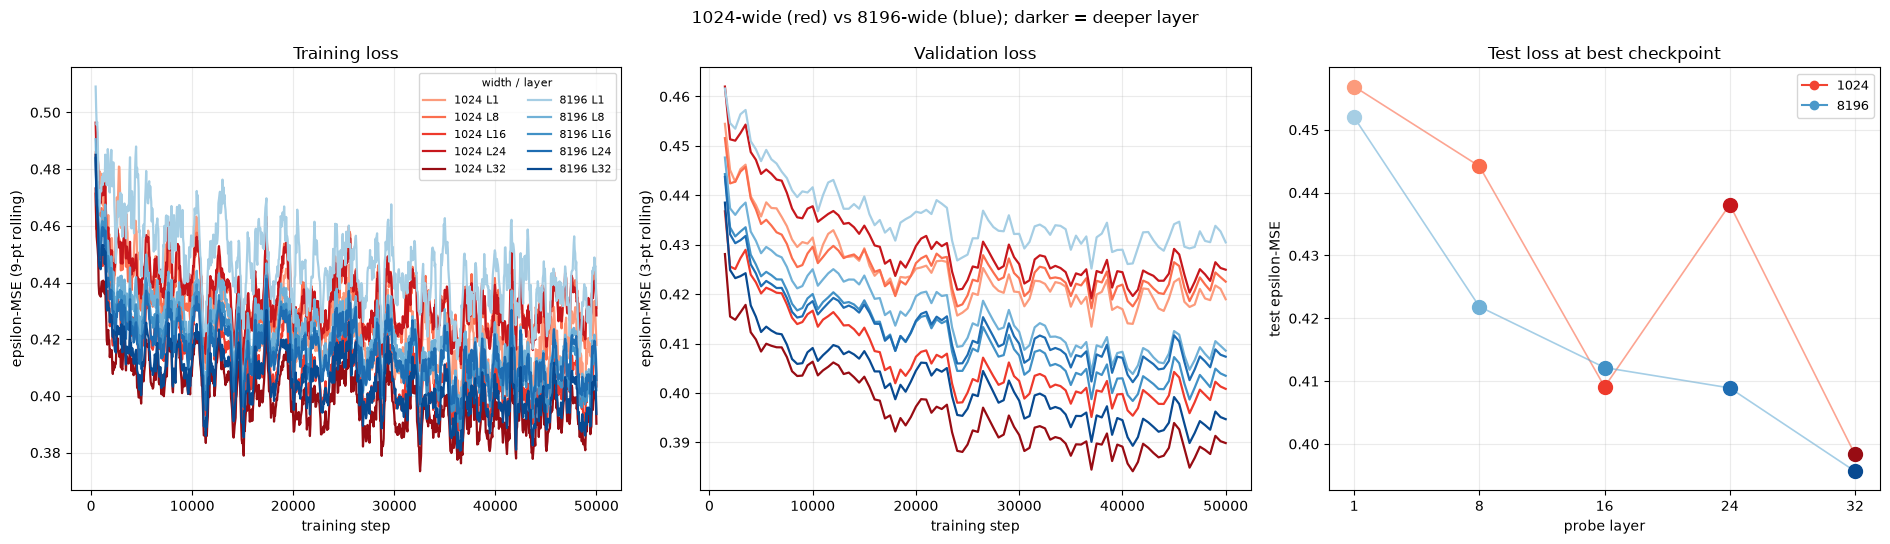

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
ax_tr, ax_va, ax_te = axes
shades = np.linspace(0.35, 0.9, len(LAYERS))
cmap = {"1024": plt.cm.Reds, "8196": plt.cm.Blues}

for width in ("1024", "8196"):
    for shade, layer in zip(shades, LAYERS):
        s, y = curves[(width, "train", layer)]
        sm = np.convolve(y, np.ones(9) / 9, mode="valid")
        ax_tr.plot(s[8:], sm, color=cmap[width](shade), lw=1.6, label=f"{width} L{layer}")

        s, y = curves[(width, "val", layer)]
        sm = np.convolve(y, np.ones(3) / 3, mode="valid")
        ax_va.plot(s[2:], sm, color=cmap[width](shade), lw=1.6)

x = np.arange(len(LAYERS))
for width in ("1024", "8196"):
    ys = [summary[width][l]["test_loss"] for l in LAYERS]
    ax_te.plot(x, ys, "-", color=cmap[width](0.5), lw=1.2, alpha=0.6, zorder=1)
for i, (shade, layer) in enumerate(zip(shades, LAYERS)):
    for width in ("1024", "8196"):
        ax_te.plot(x[i], summary[width][layer]["test_loss"], "o",
                   color=cmap[width](shade), ms=10, zorder=2)

ax_tr.set_title("Training loss")
ax_tr.set_xlabel("training step")
ax_tr.set_ylabel("epsilon-MSE (9-pt rolling)")
ax_tr.legend(ncol=2, fontsize=8, title="width / layer", title_fontsize=8)
ax_tr.grid(alpha=0.25)

ax_va.set_title("Validation loss")
ax_va.set_xlabel("training step")
ax_va.set_ylabel("epsilon-MSE (3-pt rolling)")
ax_va.grid(alpha=0.25)

ax_te.set_title("Test loss at best checkpoint")
ax_te.set_xticks(x, [str(l) for l in LAYERS])
ax_te.set_xlabel("probe layer")
ax_te.set_ylabel("test epsilon-MSE")
ax_te.grid(alpha=0.25)
ax_te.legend(handles=[
    plt.Line2D([], [], color=cmap["1024"](0.6), marker="o", ls="-", label="1024"),
    plt.Line2D([], [], color=cmap["8196"](0.6), marker="o", ls="-", label="8196"),
], fontsize=9)

fig.suptitle("1024-wide (red) vs 8196-wide (blue); darker = deeper layer")
fig.tight_layout()
fig.savefig(ROOT / "notebooks" / "training_loss.png", dpi=160)
plt.show()

Notes: the 1024 runs bottom out earlier (best checkpoints at 4k-17k steps) while
the 8196 runs keep improving to 37k-40.5k. Deeper-layer curves sit lower for 8196
(more capacity), except layer 1 where the two widths are essentially tied.